# Global Vessel Insurance Agent - Backend EDA

This notebook checks the CSV files used by the Flask backend: raw accident data, fleet size data, Paris MoU data, and the merged risk-score dataset.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

BACKEND_DIR = Path.cwd()
if BACKEND_DIR.name != 'backend':
    BACKEND_DIR = BACKEND_DIR / 'backend'
sys.path.insert(0, str(BACKEND_DIR))

from data_pipeline import build_output_csvs, read_csv

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

## Build Derived CSVs

Run this cell whenever the source CSV/PDF files change.

In [2]:
build_output_csvs()

{'paris_mou_rows': 69,
 'accident_risk_rows': 118,
 'merged_rows': 223,
 'outputs': ['/Users/yoshikiyamaguchi/Desktop/Global-Vessel-Insurance-Agent/backend/paris_mou_2024.csv',
  '/Users/yoshikiyamaguchi/Desktop/Global-Vessel-Insurance-Agent/backend/accident_risk_by_flag.csv',
  '/Users/yoshikiyamaguchi/Desktop/Global-Vessel-Insurance-Agent/backend/merged_vessel_risk_by_flag.csv']}

## Load Data

In [3]:
def load_backend_csv(filename):
    return pd.DataFrame(read_csv(BACKEND_DIR / filename))

accidents = load_backend_csv('accident_data_2020200101_20250508.csv')
fleet = load_backend_csv('Num_of_ships_by_flag.csv')
paris = load_backend_csv('paris_mou_2024.csv')
merged = load_backend_csv('merged_vessel_risk_by_flag.csv')

numeric_columns = {
    'fleet': ['2025_Number_of_ships_Value'],
    'paris': ['paris_excess_factor', 'flag_safety_risk'],
    'merged': [
        'fleet_size',
        'accident_count',
        'accident_rate',
        'avg_severity_risk',
        'avg_ship_type_risk',
        'flag_safety_risk',
        'risk_score',
        'accident_rate_norm',
        'severity_risk_norm',
        'ship_type_risk_norm',
        'flag_safety_risk_norm',
    ],
}

for column in numeric_columns['fleet']:
    fleet[column] = pd.to_numeric(fleet[column], errors='coerce')
for column in numeric_columns['paris']:
    paris[column] = pd.to_numeric(paris[column], errors='coerce')
for column in numeric_columns['merged']:
    merged[column] = pd.to_numeric(merged[column], errors='coerce')

for name, df in {
    'accidents': accidents,
    'fleet': fleet,
    'paris': paris,
    'merged': merged,
}.items():
    print(f'{name}: {df.shape[0]} rows x {df.shape[1]} columns')

accidents: 1488 rows x 15 columns
fleet: 236 rows x 3 columns
paris: 69 rows x 11 columns
merged: 223 rows x 18 columns


## Raw Data Overview

In [4]:
display(accidents.head())
display(fleet.head())
display(paris.head())
display(merged.head())

,Reference,Number of ships involved,Ships involved,SOLAS status,Flag Administrations,Ship types,Occurrence date and time,Casualty event,Casualty severity,Coordinates,Place,Location,Number of investigation reports,Administrations submitting investigation reports,None
0,C1000955,1,DURA BULK (IMO 7325461),DURA BULK (IMO 7325461): Y,Panama,General Cargo,2026-02-28 19:00,Flooding/foundering - flooding,Very serious marine casualty,27° 21.00' N 13° 30.00' W,,Coastal waters,0,,NaN
1,C1000984,1,AL SALAM II (IMO 9328168),AL SALAM II (IMO 9328168): Y,Kuwait,Container,2026-02-26 20:10,Others - Others,Marine incident,25° 34.00' N 54° 46.98' E,Arabian Gulf,Open sea,1,Kuwait,NaN
2,C1000958,1,ВН 8112,ВН 8112: N,Bulgaria,Fish Catching,2026-02-18 08:37,Flooding/foundering - foundering,Very serious marine casualty,42° 21.00' N 27° 53.00' E,Black Sea,Coastal waters,0,,NaN
3,C1000934,1,Dream 1 (IMO 8967187),Dream 1 (IMO 8967187): U,Comoros,Other Bulk Dry,2026-02-08 04:00,Flooding/foundering - foundering,Very serious marine casualty,29° 14.05' N 48° 41.20' E,Kuwaiti EEZ,Open sea,0,,NaN
4,C1000960,1,TRISHA KERSTIN 3 (IMO 9125516),TRISHA KERSTIN 3 (IMO 9125516):,Philippines,Passenger/Ro-Ro Cargo,2026-01-21 01:21,Others - Others,Very serious marine casualty,6° 40.49' N 121° 44.55' E,abeam Baluk-Baluk Island,Coastal waters,1,Philippines,NaN


,Economy_Label,2025_Number_of_ships_Value,2025_Number_of_ships_MissingValue
0,Africa,10620.0,
1,Northern Africa,849.0,
2,Sub-Saharan Africa,9771.0,
3,Eastern Africa,1197.0,
4,Middle Africa,569.0,


,flag,flag_key,paris_mou_category,paris_rank,paris_inspections_2022_2024,paris_detentions_2022_2024,paris_black_to_grey_limit,paris_grey_to_white_limit,paris_risk_text,paris_excess_factor,flag_safety_risk
0,France,france,white,1,297,1,29,13,,-1.78,0.0
1,Denmark,denmark,white,2,1246,14,103,72,,-1.75,0.0
2,Norway,norway,white,3,1824,23,146,109,,-1.74,0.0
3,Netherlands,netherlands,white,4,2690,46,211,166,,-1.61,0.0
4,Singapore,singapore,white,5,1745,28,140,104,,-1.61,0.0


,flag,flag_key,fleet_size,accident_count,accident_rate,accident_rate_norm,avg_severity_risk,severity_risk_norm,avg_ship_type_risk,ship_type_risk_norm,paris_mou_category,paris_rank,paris_inspections_2022_2024,paris_detentions_2022_2024,paris_excess_factor,flag_safety_risk,flag_safety_risk_norm,risk_score
0,Cameroon,cameroon,240,3,0.012500,0.012500,0.883333,0.883333,0.842742,0.842742,black,69,144,43,6.56,1.0,1.0,0.684644
1,Guinea-Bissau,guinea bissau,74,4,0.054054,0.054054,0.825000,0.825000,0.850806,0.850806,black,61,51,9,1.94,1.0,1.0,0.682465
2,Anguilla,anguilla,1,1,1.000000,1.000000,1.000000,1.000000,0.217742,0.217742,unlisted,,,,,0.5,0.5,0.679435
3,Comoros,comoros,432,15,0.034722,0.034722,0.953333,0.953333,0.555108,0.555108,black,65,258,48,3.59,1.0,1.0,0.635791
4,Palau,palau,565,18,0.031858,0.031858,0.877778,0.877778,0.621192,0.621192,black,60,489,55,1.67,1.0,1.0,0.632707


## Missing Values

In [5]:
for name, df in {'accidents': accidents, 'fleet': fleet, 'paris': paris, 'merged': merged}.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f'\n{name}')
    display(missing.to_frame('missing_count'))


accidents


,missing_count
None,1486



fleet


,missing_count
2025_Number_of_ships_Value,13



paris


,missing_count



merged


,missing_count


## Accident Data Distributions

In [6]:
display(accidents['Flag Administrations'].value_counts().head(15).to_frame('records'))
display(accidents['Casualty severity'].value_counts().to_frame('records'))
display(accidents['Ship types'].value_counts().head(15).to_frame('records'))

,records
Flag Administrations,
Panama,201
Malta,98
Liberia,98
"Hong Kong, China",56
Marshall Islands,50
United Kingdom,42
France,40
Singapore,39
Argentina,38


,records
Casualty severity,
Very serious marine casualty,995
Marine casualty,379
Marine incident,113
2023-04-17 07:45,1


,records
Ship types,
Bulk Dry,248
General Cargo,211
Fish Catching,175
Container,132
Oil Tanker,84
Chemical Tanker,76
Passenger,54
Other Activities,46
Passenger/Ro-Ro Cargo,42


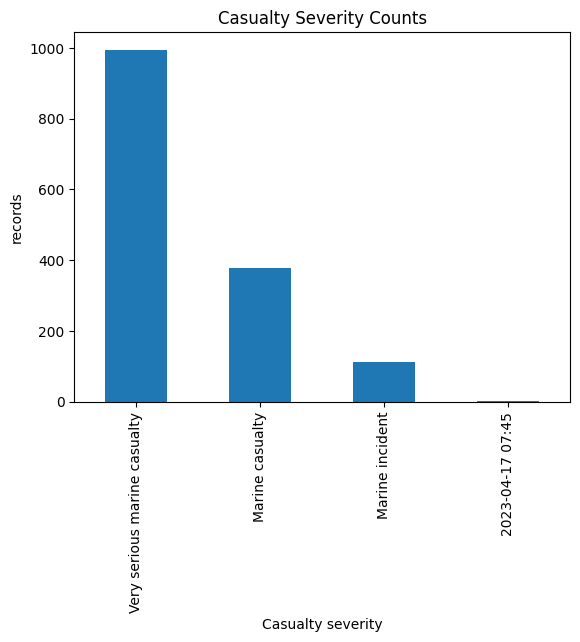

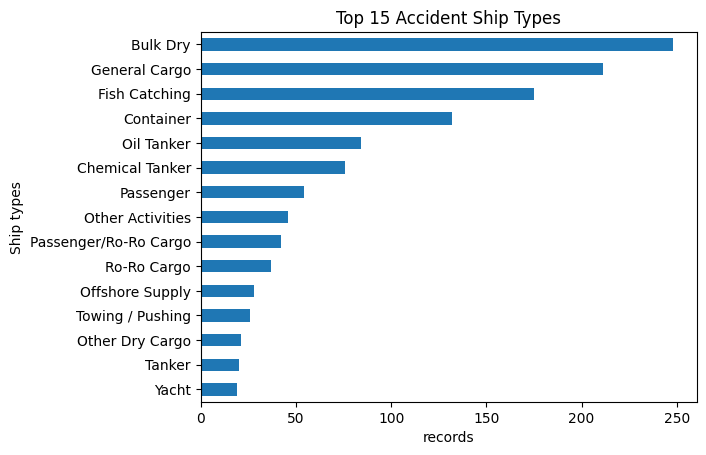

In [7]:
accidents['Casualty severity'].value_counts().plot(kind='bar', title='Casualty Severity Counts')
plt.ylabel('records')
plt.show()

accidents['Ship types'].value_counts().head(15).sort_values().plot(kind='barh', title='Top 15 Accident Ship Types')
plt.xlabel('records')
plt.show()

## Fleet, Paris MoU, And Risk Scores

In [8]:
display(fleet['2025_Number_of_ships_Value'].describe())
display(paris['paris_mou_category'].value_counts().to_frame('flags'))

risk_columns = [
    'fleet_size',
    'accident_count',
    'accident_rate',
    'avg_severity_risk',
    'avg_ship_type_risk',
    'flag_safety_risk',
    'risk_score',
]
display(merged[risk_columns].describe())

count      223.000000
mean      1605.838565
std       4985.229815
min          1.000000
25%         29.500000
50%        116.000000
75%        705.000000
max      53323.000000
Name: 2025_Number_of_ships_Value, dtype: float64

,flags
paris_mou_category,
white,40
grey,17
black,12


,fleet_size,accident_count,accident_rate,avg_severity_risk,avg_ship_type_risk,flag_safety_risk,risk_score
count,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000
mean,584.726457,7.125561,0.017843,0.432307,0.197473,0.437220,0.271211
std,2033.004842,20.322012,0.070908,0.435148,0.252442,0.233665,0.164267
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.125000
50%,69.000000,1.000000,0.000000,0.350000,0.008065,0.500000,0.236624
75%,356.500000,5.000000,0.017321,0.883333,0.382140,0.500000,0.392414
max,23545.000000,216.000000,1.000000,1.000000,1.000000,1.000000,0.684644


In [9]:
display(merged.sort_values('risk_score', ascending=False).head(20)[[
    'flag',
    'fleet_size',
    'accident_count',
    'accident_rate_norm',
    'severity_risk_norm',
    'ship_type_risk_norm',
    'flag_safety_risk_norm',
    'risk_score',
    'paris_mou_category',
]])

,flag,fleet_size,accident_count,accident_rate_norm,severity_risk_norm,ship_type_risk_norm,flag_safety_risk_norm,risk_score,paris_mou_category
0,Cameroon,240,3,0.012500,0.883333,0.842742,1.0,0.684644,black
1,Guinea-Bissau,74,4,0.054054,0.825000,0.850806,1.0,0.682465,black
2,Anguilla,1,1,1.000000,1.000000,0.217742,0.5,0.679435,unlisted
3,Comoros,432,15,0.034722,0.953333,0.555108,1.0,0.635791,black
4,Palau,565,18,0.031858,0.877778,0.621192,1.0,0.632707,black
5,Vanuatu,295,9,0.030508,0.800000,0.689068,1.0,0.629894,black
6,Togo,355,10,0.028169,0.815000,0.668952,1.0,0.628030,black
7,Sri Lanka,95,1,0.010526,1.000000,1.000000,0.5,0.627632,unlisted
8,Belize,769,9,0.011704,1.000000,0.488799,1.0,0.625126,black
9,Bolivia (Plurinational State of),54,1,0.018519,1.000000,0.842742,0.5,0.590315,unlisted


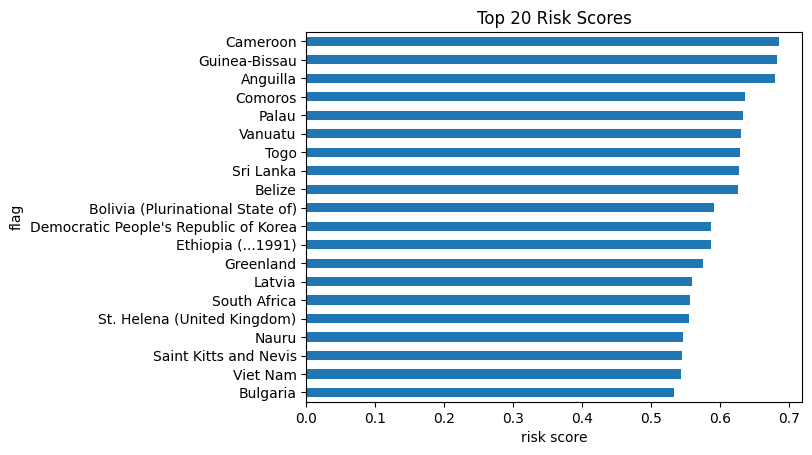

In [10]:
merged.sort_values('risk_score', ascending=False).head(20).sort_values('risk_score').plot(
    kind='barh', x='flag', y='risk_score', legend=False, title='Top 20 Risk Scores'
)
plt.xlabel('risk score')
plt.show()